# EDA - LinkedIn CVs 

This notebook presents an EDA for predicting Department and Seniority from job titles.

**Main Topics:**
- How large and clean are the labeled CSVs?
- How imbalanced are the labels?
- What do job titles look like (length, characters)?
- How is the annotated JSON structured, and how can we derive a fair evaluation subset?

**Structure:**
1. Setup
2. Data Paths
3. Load Labeled CSVs (training)
4. Label balance (training CSVs)
5. Text sanity checks (training CSVs)
6. Languages in the CSVs (quick heuristic)
7. Train/validation split sanity check
8. JSON reality check (evaluation data)

**Data sources:**
- department-v2.csv: job titles labeled with Department
- seniority-v2.csv: job titles labeled with Seniority
- linkedin-cvs-annotades.json: CVs with Department and Seniority per job


## 1. Setup

In [4]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

## 2. Data Paths


In [5]:
cwd = Path.cwd()

if (cwd / "Data" / "Original Data").exists():
    DATA_DIR = cwd / "Data" / "Original Data"
elif (cwd.parent / "Data" / "Original Data").exists():
    DATA_DIR = cwd.parent / "Data" / "Original Data"
else:
    raise FileNotFoundError("Could not find data directory (expected Data/Original Data).")

paths = {
    "department_csv": DATA_DIR / "department-v2.csv",
    "seniority_csv": DATA_DIR / "seniority-v2.csv",
    "json_annotated": DATA_DIR / "linkedin-cvs-annotated.json",
    "json_unannotated": DATA_DIR / "linkedin_cvs_not_annotated",
}
paths


{'department_csv': PosixPath('/home/dom/Code/githuub push/PracticalDataScience/Data/Original Data/department-v2.csv'),
 'seniority_csv': PosixPath('/home/dom/Code/githuub push/PracticalDataScience/Data/Original Data/seniority-v2.csv'),
 'json_annotated': PosixPath('/home/dom/Code/githuub push/PracticalDataScience/Data/Original Data/linkedin-cvs-annotated.json'),
 'json_unannotated': PosixPath('/home/dom/Code/githuub push/PracticalDataScience/Data/Original Data/linkedin_cvs_not_annotated')}

## 3. Load Labeled CSVs (training)
These CSVs provide clean job title examples with labels for Department and Seniority.

In [6]:
dept_df = pd.read_csv(paths["department_csv"])
sen_df = pd.read_csv(paths["seniority_csv"])

print("Department shape:", dept_df.shape)
print("Seniority shape:", sen_df.shape)

dept_df.head()


Department shape: (10145, 2)
Seniority shape: (9428, 2)


,text,label
0,Adjoint directeur communication,Marketing
1,Advisor Strategy and Projects,Project Management
2,Beratung & Projekte,Project Management
3,Beratung & Projektmanagement,Project Management
4,Beratung und Projektmanagement kommunale Partner,Project Management


In [7]:
sen_df.head()

,text,label
0,Analyst,Junior
1,Analyste financier,Junior
2,Anwendungstechnischer Mitarbeiter,Junior
3,Application Engineer,Senior
4,Applications Engineer,Senior


In [8]:
dept_df.info()
sen_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10145 entries, 0 to 10144
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    10145 non-null  object
 1   label   10145 non-null  object
dtypes: object(2)
memory usage: 158.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9428 entries, 0 to 9427
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    9428 non-null   object
 1   label   9428 non-null   object
dtypes: object(2)
memory usage: 147.4+ KB


In [9]:
dept_df.nunique()


text     10145
label       11
dtype: int64

### Interpretation (after info() + nunique())
The two CSV files contain only text and label, both stored as string/object types, which is appropriate for text classification.
The number of unique titles is very close to the total number of rows, indicating low duplication and high title variety. This reduces the risk of inflated model performance due to identical titles appearing multiple times.

## 4. Label balance (training CSVs)

Before building any model, we check whether the target labels are balanced.
Why this matters:

- Imbalanced labels usually lead to biased predictions (models prefer majority classes).
- It also affects how we split into train/validation: we want the validation set to contain all classes.

### 4.1 Department label distribution 

In [10]:
dept_df["label"].value_counts()

label
Marketing                 4295
Sales                     3328
Information Technology    1305
Business Development       620
Project Management         201
Consulting                 167
Administrative              83
Other                       42
Purchasing                  40
Customer Support            33
Human Resources             31
Name: count, dtype: int64

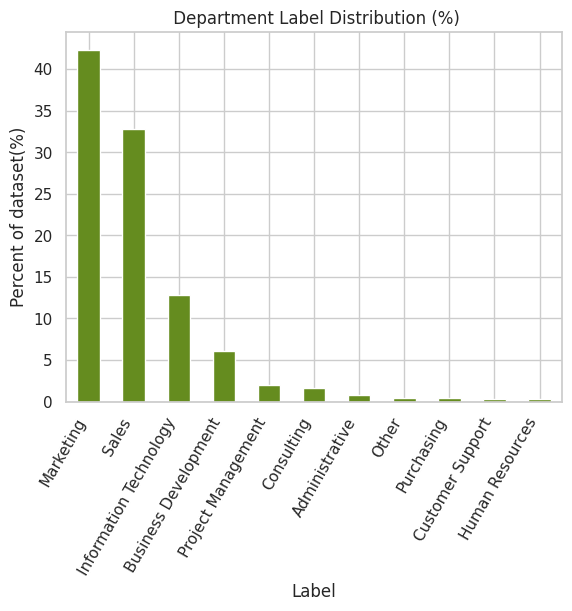

In [11]:
dep_percentage = dept_df["label"].value_counts(normalize=True) * 100

dep_percentage.plot(kind="bar", color="#658C1F")
plt.title(" Department Label Distribution (%)")
plt.xlabel("Label")
plt.xticks(rotation=60, ha="right")
plt.ylabel("Percent of dataset(%)")
plt.grid(True)





### 4.2 Seniority label distribution

In [12]:
sen_df["label"].value_counts()

label
Senior        3733
Lead          3546
Director       984
Management     756
Junior         409
Name: count, dtype: int64

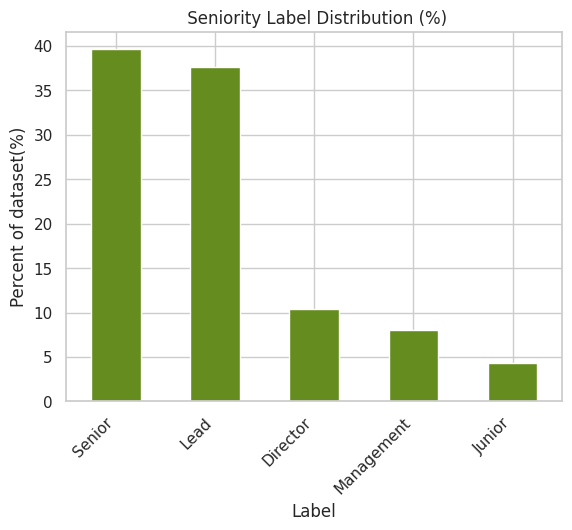

In [13]:
sen_percentage = sen_df["label"].value_counts(normalize=True) * 100

sen_percentage.plot(kind="bar", color="#658C1F")
plt.title(" Seniority Label Distribution (%)")
plt.xlabel("Label")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Percent of dataset(%)")
plt.grid(True)

### Interpretation

The label distributions show that both tasks are clearly imbalanced: a few classes dominate the dataset while several labels occur only a few dozen times. 
In a supervised setting, this typically means the model will struggle to learn robust patterns for rare labels, so we should expect the largest errors precisely in those low-frequency departments and keep performance expectations realistic there. 
This imbalance also makes accuracy a weak standalone metric, because it is driven mainly by the majority classes: a model can achieve high accuracy by predicting common labels most of the time while still performing poorly on rare (but often important) classes.

For a fair evaluation, we should therefore report Macro-F1 in addition to accuracy, and include per-class precision/recall/F1 (or a confusion matrix) to make performance on rare labels visible. The same issue motivates stratified train/test splits and, if needed later, techniques such as class weighting, resampling, data augmentation, or threshold tuning to improve minority-class performance.


## 5. Text sanity checks (training CSVs)

The CSV texts are job titles, so they are short.
We still want to check two things:

1. Length: extremely short titles tend to be ambiguous.
2. Multilinguality: if the data is multilingual, we may want a translation step (or a multilingual model).

### 5.1 Department: title length distribution

We plot the number of words per title.
This gives a quick feeling for how much information the model can realistically use.

,value
count,10145.000000
mean,4.263677
std,1.945473
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,28.000000


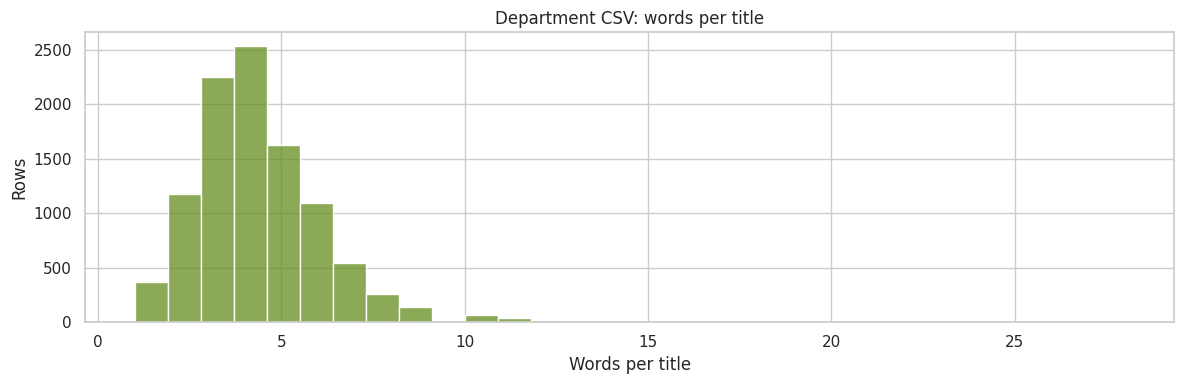

In [14]:
dept_words = dept_df["text"].fillna("").astype(str).str.split().map(len)
display(dept_words.describe().to_frame("value"))

plt.figure(figsize=(12, 4))
sns.histplot(dept_words, bins=30, color="#658C1F")
plt.title("Department CSV: words per title")
plt.xlabel("Words per title")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

### Interpretation
If most titles are 1–3 words, the model mainly learns from keywords.
That is fine for a baseline, but it also explains why department and seniority can be hard when titles are generic (e.g., “Consultant”).


### 5.2 Seniority: title length distribution

We repeat the same length check for the seniority dataset.
This matters because seniority often depends on subtle wording (e.g., *Lead* vs *Senior*)
and very short titles leave little room for those cues.


,value
count,9428.000000
mean,4.319474
std,1.917458
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,25.000000


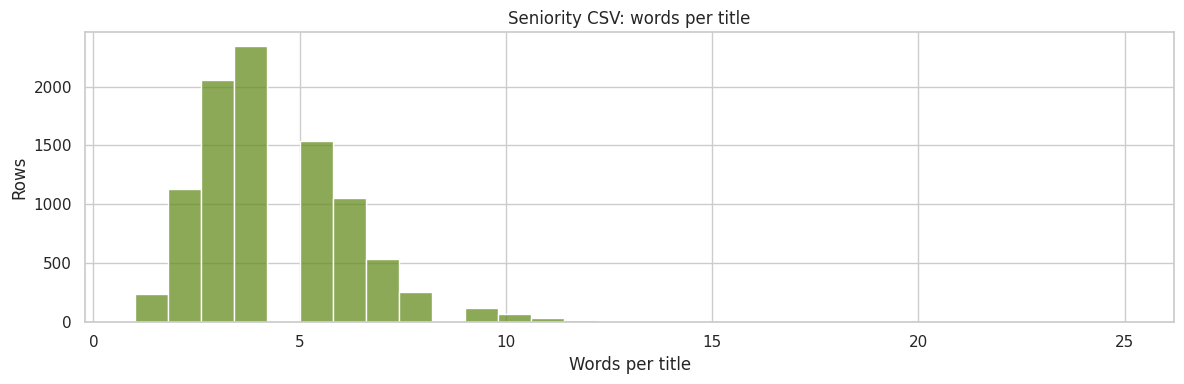

In [15]:
sen_words = sen_df["text"].fillna("").astype(str).str.split().map(len)
display(sen_words.describe().to_frame("value"))

plt.figure(figsize=(12, 4))
sns.histplot(sen_words, bins=30, color="#658C1F")
plt.title("Seniority CSV: words per title")
plt.xlabel("Words per title")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

### Interpretation
Seniority cues are often weaker than domain cues.
Even long titles may not clearly encode seniority, so we expect seniority models to benefit more from context (previous jobs) later.


## 6. Languages in the CSVs (quick heuristic)

The CSV files do not include a language column. As a quick sanity check for multilinguality, we simply look for non‑ASCII characters in job titles (e.g., accents like á/ö/ß or non‑Latin scripts). 
This is not language detection, but it is enough to confirm that the text is not strictly English/ASCII. 
This matters because multilingual text increases vocabulary variation and can affect preprocessing and model performance; if the share is substantial, we might later consider normalization, multilingual models, or translation.

### 6.1 Languages in the Department CSV (quick heuristic)

In [16]:
text = dept_df["text"].fillna("").astype(str)
has_non_ascii = text.str.contains(r"[^\x00-\x7F]", na=False)

print("non-ascii rows:", has_non_ascii.sum(), "of", len(text))
print("share:", round(100 * has_non_ascii.mean(), 2), "%")
print(text[has_non_ascii].head(10).to_string(index=False))



non-ascii rows: 725 of 10145
share: 7.15 %
                           Chargé de communication
                  Chargé de communication digitale
              Chargé de communication et marketing
                    Chargé de Webmarketing SEO/SEA
            Chargée data marketing & communication
              Chargée de communication - Graphiste
              Chargée de communication & marketing
Chargée de communication / Chef de projet événe...
          Chargée de communication et événementiel
         Chargée de communication et événementiels


### 6.2 Languages in the Seniority CSV (quick heuristic)

In [17]:
text = sen_df["text"].fillna("").astype(str)
has_non_ascii = text.str.contains(r"[^\x00-\x7F]", na=False)

print("non-ascii rows:", has_non_ascii.sum(), "of", len(text))
print("share:", round(100 * has_non_ascii.mean(), 2), "%")
print(text[has_non_ascii].head(10).to_string(index=False))


non-ascii rows: 919 of 9428
share: 9.75 %
Chargée de communication / Chef de projet événe...
Chef de marché Résidences services senior - Sol...
                       Chef de projet Évènementiel
   Chef de Projet Événementiel / Event Coordinator
               Chef de Projet Systèmes et Services
   Mitarbeiterin Presse- und Öffentlichkeitsarbeit
                    Referent Öffentlichkeitsarbeit
     Referentin für Prozess- und Projektmanagement
Referentin für Unternehmensentwicklung und Vert...
          Referentin für Unternehmenskommunikation


### Interpretation 
Across both CSVs we observe a small but non‑trivial share of non‑ASCII job titles (Department: ~7%, Seniority: ~10%). This suggests the data is not strictly “English/ASCII-only” and includes titles with accents or other language-specific characters. While this is only a lightweight heuristic (not true language detection), it is sufficient to motivate Unicode-safe preprocessing and to keep multilingual handling in mind later (e.g., normalization or multilingual models instead of assuming English everywhere).

## 7. Train/validation split sanity check 

We will train models on the Deprtment & Seniority CSV

Below we plot the **absolute counts** for each label in train vs validation.


### 7.1 Department

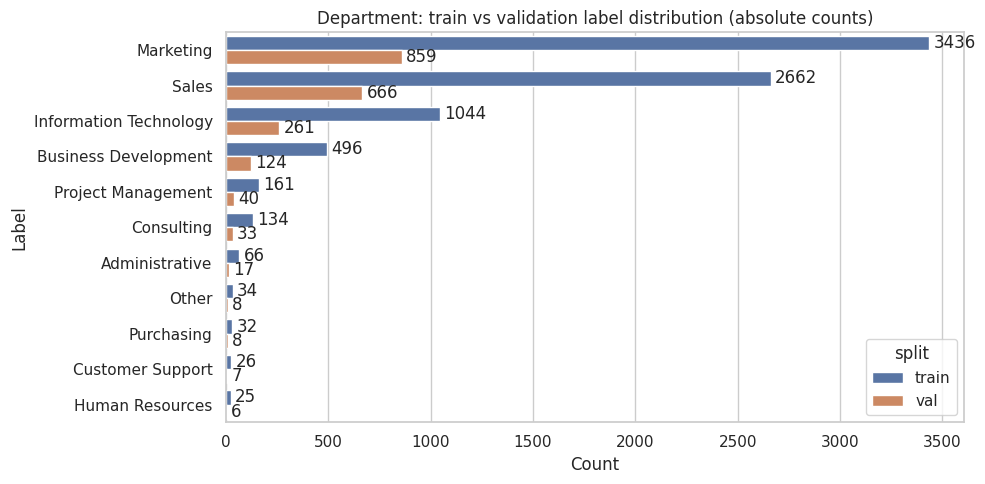

In [18]:
dept_train, dept_val = train_test_split(
    dept_df,
    test_size=0.2,
    random_state=0,
    stratify=dept_df["label"],
)

plot_df = pd.concat([
    dept_train.assign(split="train"),
    dept_val.assign(split="val"),
])

order = dept_df["label"].value_counts().index
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=plot_df, y="label", hue="split", order=order)
ax.set_title("Department: train vs validation label distribution (absolute counts)")
ax.set_xlabel("Count")
ax.set_ylabel("Label")
for c in ax.containers:
    ax.bar_label(c, fmt="%d", padding=3)
plt.tight_layout()
plt.show()

### Interpretation 
This plot is mostly a sanity check it shows a strong long-tail imbalance.
Marketing and Sales dominate, while several departments have only a small number of examples
Once we move to fine-tuning, we can keep the same split strategy (or use cross-validation).

### 7.2 Seniority

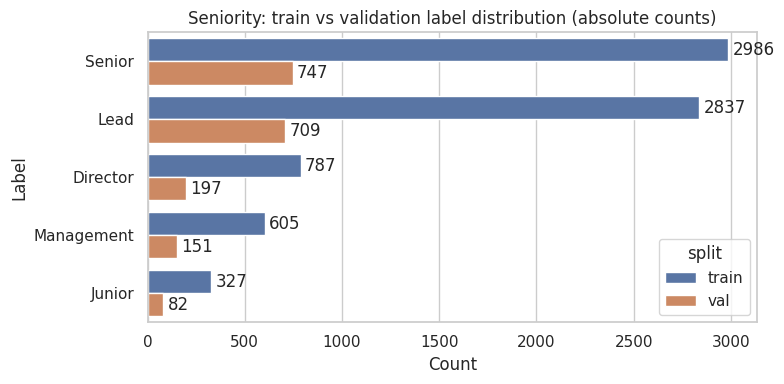

In [19]:
sen_train, sen_val = train_test_split(
    sen_df,
    test_size=0.2,
    random_state=0,
    stratify=sen_df["label"],
)

plot_df = pd.concat([
    sen_train.assign(split="train"),
    sen_val.assign(split="val"),
])

order = sen_df["label"].value_counts().index
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=plot_df, y="label", hue="split", order=order)
ax.set_title("Seniority: train vs validation label distribution (absolute counts)")
ax.set_xlabel("Count")
ax.set_ylabel("Label")
for c in ax.containers:
    ax.bar_label(c, fmt="%d", padding=3)
plt.tight_layout()
plt.show()


### Interpretation
This plot is mainly a sanity check: because we use a stratified split, the label distribution stays very similar between train and validation (no accidental skew introduced by the split). 
At the same time, it highlights strong class imbalance
Senior and Lead dominate, while Junior, Management, and Director are much rarer so we expect the largest errors on these minority classes. 
Therefore, accuracy alone is not sufficient; we should report Macro-F1 and per-class metrics in addition to accuracy.

## 8. JSON reality check (evaluation data)

The training CSVs are clean and controlled.
But the real task is to predict labels for **current jobs** inside the LinkedIn CV JSONs.

So now we look at the annotated JSON and answer:

- How many "current jobs" exist per CV?
- What does the label distribution look like in evaluation?
- Is the evaluation label space compatible with the training label space?

### 8.1 Load annotated JSON and flatten to job rows

The JSON is a list of CVs, and each CV is a list of jobs.
For analysis, it is easier to work in a job-level table.

In [20]:
with open(paths["json_annotated"], "r", encoding="utf-8") as f:
    cvs = json.load(f)

rows = []
for cv_id, jobs in enumerate(cvs):
    for job_index, job in enumerate(jobs):
        rows.append({"cv_id": cv_id, "job_index": job_index, **job})

jobs_df = pd.DataFrame(rows)

display({"cvs": len(cvs), "jobs": len(jobs_df)})
display(jobs_df.head(3))
display(jobs_df["status"].value_counts())

{'cvs': 609, 'jobs': 2638}

,cv_id,job_index,organization,linkedin,position,startDate,endDate,status,department,seniority
0,0,0,Depot4Design GmbH,https://www.linkedin.com/company/depot4design-...,Prokurist,2019-08,None,ACTIVE,Other,Management
1,0,1,Depot4Design GmbH,https://www.linkedin.com/company/depot4design-...,CFO,2019-07,None,ACTIVE,Other,Management
2,0,2,Depot4Design GmbH,https://www.linkedin.com/company/depot4design-...,Betriebswirtin,2019-07,None,ACTIVE,Other,Professional


status
INACTIVE    1897
ACTIVE       623
UNKNOWN      118
Name: count, dtype: int64

### 8.2 ACTIVE jobs per CV

In theory, every CV should have exactly one current job.
In practice, the JSON can contain:

- **0 ACTIVE jobs** (missing current job)
- **1 ACTIVE job** (ideal)
- **>1 ACTIVE jobs** (ambiguous current job)

We plot the distribution because it directly influences our evaluation logic.

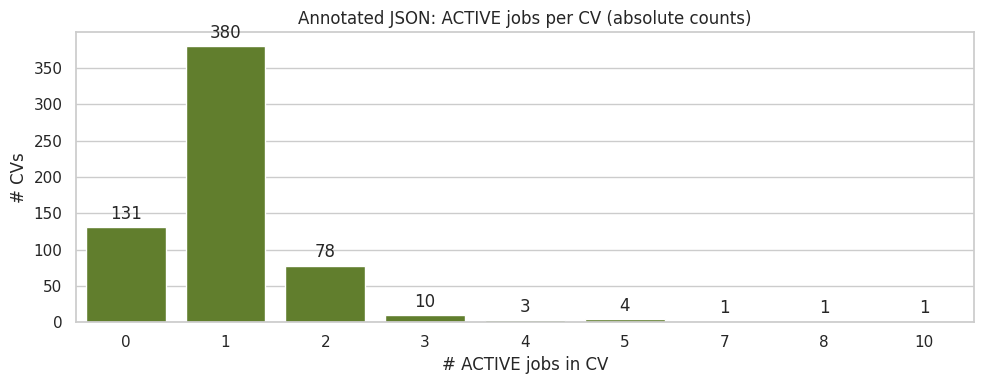

In [21]:
active_jobs = jobs_df[jobs_df["status"] == "ACTIVE"].copy()

all_cvs = jobs_df["cv_id"].unique()
active_counts = active_jobs.groupby("cv_id").size()

active_per_cv = pd.Series(0, index=all_cvs, dtype=int)
active_per_cv.loc[active_counts.index] = active_counts.astype(int)

plt.figure(figsize=(10, 4))
ax = sns.countplot(x=active_per_cv, color="#658C1F")
ax.set_title("Annotated JSON: ACTIVE jobs per CV (absolute counts)")
ax.set_xlabel("# ACTIVE jobs in CV")
ax.set_ylabel("# CVs")
ax.bar_label(ax.containers[0], fmt="%d", padding=3)
plt.tight_layout()
plt.show()

### Interpretation
If we have CVs with 0 or >1 ACTIVE jobs, we need a deterministic rule.
For the rest of the notebook we select one current job per CV(latest start date, with a simple fallback).

### 8.3 Define one “current job” per CV

Rule used here:

1. Keep only jobs with "status == "ACTIVE"".
2. If a CV has multiple ACTIVE jobs, select the one with the **latest "startDate"**.
3. If "startDate" is missing, we fall back to the job order ("job_index").

In [22]:
active_jobs = active_jobs.copy()
active_jobs["start_dt"] = pd.to_datetime(active_jobs["startDate"], errors="coerce")

current_jobs = (
    active_jobs
    .sort_values(["cv_id", "start_dt", "job_index"])
    .groupby("cv_id", as_index=False)
    .tail(1)
    .drop(columns=["start_dt"])
)

summary = {
    "CVs total": len(cvs),
    "CVs with >=1 ACTIVE": int(current_jobs["cv_id"].nunique()),
    "CVs with 0 ACTIVE": int(len(cvs) - current_jobs["cv_id"].nunique()),
    "ACTIVE jobs total": int(len(active_jobs)),
}

display(summary)
display(current_jobs[["cv_id", "position", "department", "seniority", "startDate"]].head(5))

{'CVs total': 609,
 'CVs with >=1 ACTIVE': 478,
 'CVs with 0 ACTIVE': 131,
 'ACTIVE jobs total': 623}

,cv_id,position,department,seniority,startDate
0,0,Prokurist,Other,Management,2019-08
6,1,Solutions Architect,Information Technology,Professional,2024-03
14,2,Medizintechnik Beratung,Consulting,Professional,2025-01
17,3,Director expansión de negocio.,Business Development,Director,2024-09
24,4,"APL-ansvarig, samordning",Administrative,Lead,2019-08


## 8.4 ACTIVE label distributions (evaluation)

Now we look at the *actual* distribution the models will face at evaluation time.
We again show **absolute counts** and a small table with percentages.

#### 8.4.1 Department (ACTIVE current jobs)

This is the evaluation distribution for the department task.

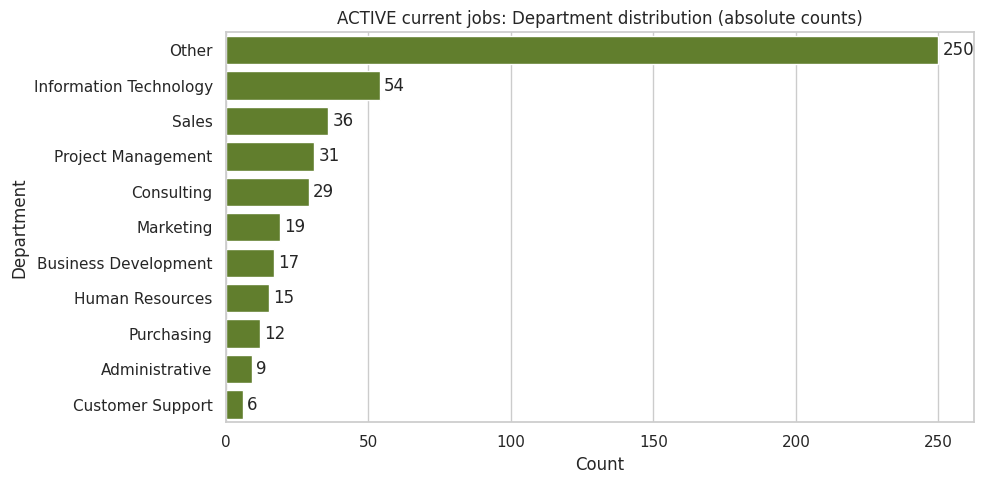

,count,pct
label,,
Other,250,52.30
Information Technology,54,11.30
Sales,36,7.53
Project Management,31,6.49
Consulting,29,6.07
Marketing,19,3.97
Business Development,17,3.56
Human Resources,15,3.14
Purchasing,12,2.51


In [23]:
dept_active = current_jobs[["department"]].dropna().rename(columns={"department": "label"})

plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=dept_active,
    y="label",
    order=dept_active["label"].value_counts().index,
    color="#658C1F",
)
ax.set_title("ACTIVE current jobs: Department distribution (absolute counts)")
ax.set_xlabel("Count")
ax.set_ylabel("Department")
ax.bar_label(ax.containers[0], fmt="%d", padding=3)
plt.tight_layout()
plt.show()

counts = dept_active["label"].value_counts().rename("count").to_frame()
counts["pct"] = (counts["count"] / counts["count"].sum() * 100).round(2)
display(counts)

### Interpretation
If "Other" dominates, the evaluation problem is harder than what the CSV alone suggests.
In that case, we may want (later) either a better label definition for "Other" or a two-stage model (Other-vs-rest, then fine labels).

#### 8.4.2 Seniority (ACTIVE current jobs)

Same evaluation distribution for seniority.

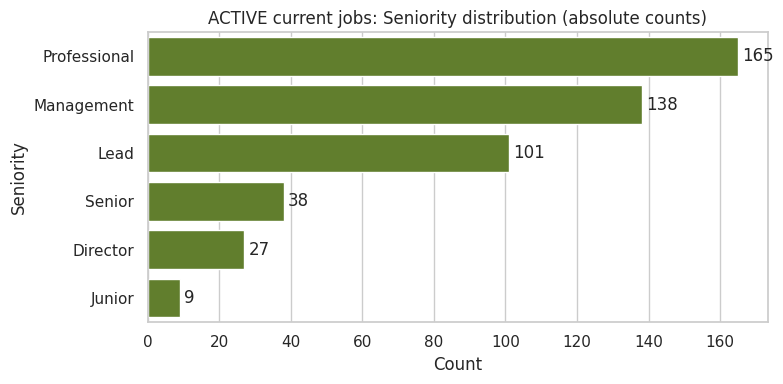

,count,pct
label,,
Professional,165,34.52
Management,138,28.87
Lead,101,21.13
Senior,38,7.95
Director,27,5.65
Junior,9,1.88


In [24]:
sen_active = current_jobs[["seniority"]].dropna().rename(columns={"seniority": "label"})

plt.figure(figsize=(8, 4))
ax = sns.countplot(
    data=sen_active,
    y="label",
    order=sen_active["label"].value_counts().index,
    color="#658C1F",
)
ax.set_title("ACTIVE current jobs: Seniority distribution (absolute counts)")
ax.set_xlabel("Count")
ax.set_ylabel("Seniority")
ax.bar_label(ax.containers[0], fmt="%d", padding=3)
plt.tight_layout()
plt.show()

counts = sen_active["label"].value_counts().rename("count").to_frame()
counts["pct"] = (counts["count"] / counts["count"].sum() * 100).round(2)
display(counts)

### Interpretation
The annotated JSON contains seniority labels not present in the training CSV label set (e.g., Professional), so we will later need to handle this mismatch explicitly (drop those rows vs. map the label).


## Key findings

- Both tasks are clearly imbalanced (long-tail labels), so we should report Macro-F1 and per-class results in addition to accuracy.

- Job titles are often short and keyword-based; this is usually more informative for department than for seniority, where cues can be subtle.

- A non-trivial share of titles contains non-ASCII characters, so preprocessing must be Unicode-safe (and multilingual variation may reduce exact-match/keyword coverage).

- Stratified splits preserve label distributions for training/validation, but performance will likely drop on the JSON current-job evaluation due to domain shift.

- For seniority, label-space mismatches (e.g., Professional) must be handled explicitly (drop vs map vs extend).
